## ==========================================
# Step 1: Import Required Libraries
# ==========================================

In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


## ==========================================
# Step 2: Load the Dataset and Remove Duplicates
# ==========================================

In [12]:
# Load the Titanic dataset from the local CSV file
df = pd.read_csv("titanic.csv")

# Remove duplicate rows from the DataFrame to ensure data quality
df = df.drop_duplicates()


## ==========================================
# Step 3: Handle Missing Values
# ==========================================

In [14]:
# Loop through all columns and fill missing values with the most frequent value (Mode)
for column in df.columns:
    if df[column].isnull().any():
        mode_value = df[column].mode()[0]
        # Avoid inplace=True to prevent FutureWarning in modern pandas
        df[column] = df[column].fillna(mode_value)

# ==========================================
# Step 4: Encode Categorical Features
# ==========================================

In [15]:
# Dictionary to keep track of the LabelEncoders for each categorical column
label_encoders = {}

# Convert all text (object) columns into numerical representations
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


## ==========================================
# Step 5: Separate Features and Target Variable
# ==========================================

In [16]:
# X contains the independent variables (features), excluding the target column
X = df.drop("Survived", axis=1)

# y contains the dependent variable (target) to predict
y = df["Survived"]


# ==========================================
# Step 6: Feature Standardization
# ==========================================


In [17]:
# Initialize the StandardScaler to scale features to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## ==========================================
# Step 7: Split Data into Train and Test Sets
# ==========================================

In [18]:
# Split the scaled dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# ==========================================
# Step 8: Train and Evaluate KNN Classifier
# ==========================================

In [19]:
# Initialize K-Nearest Neighbors Classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the KNN model on the training data
knn.fit(X_train, y_train)

# Predict the survival outcome for the test data
y_pred_knn = knn.predict(X_test)


# ==========================================
# Step 9: Train and Evaluate Decision Tree Classifier
# ==========================================

In [20]:
# Initialize Decision Tree Classifier with a fixed random state for reproducibility
dt = DecisionTreeClassifier(random_state=42)

# Fit the Decision Tree model on the training data
dt.fit(X_train, y_train)

# Predict the survival outcome for the test data
y_pred_dt = dt.predict(X_test)


## ==========================================
# Step 10: Print Accuracy Scores
# ==========================================

In [21]:
# Calculate and print the accuracy for both models to compare performance
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


KNN Accuracy: 0.8212290502793296
Decision Tree Accuracy: 0.8100558659217877


# ==========================================
# Step 11: Plot the Decision Tree Structure
# ==========================================

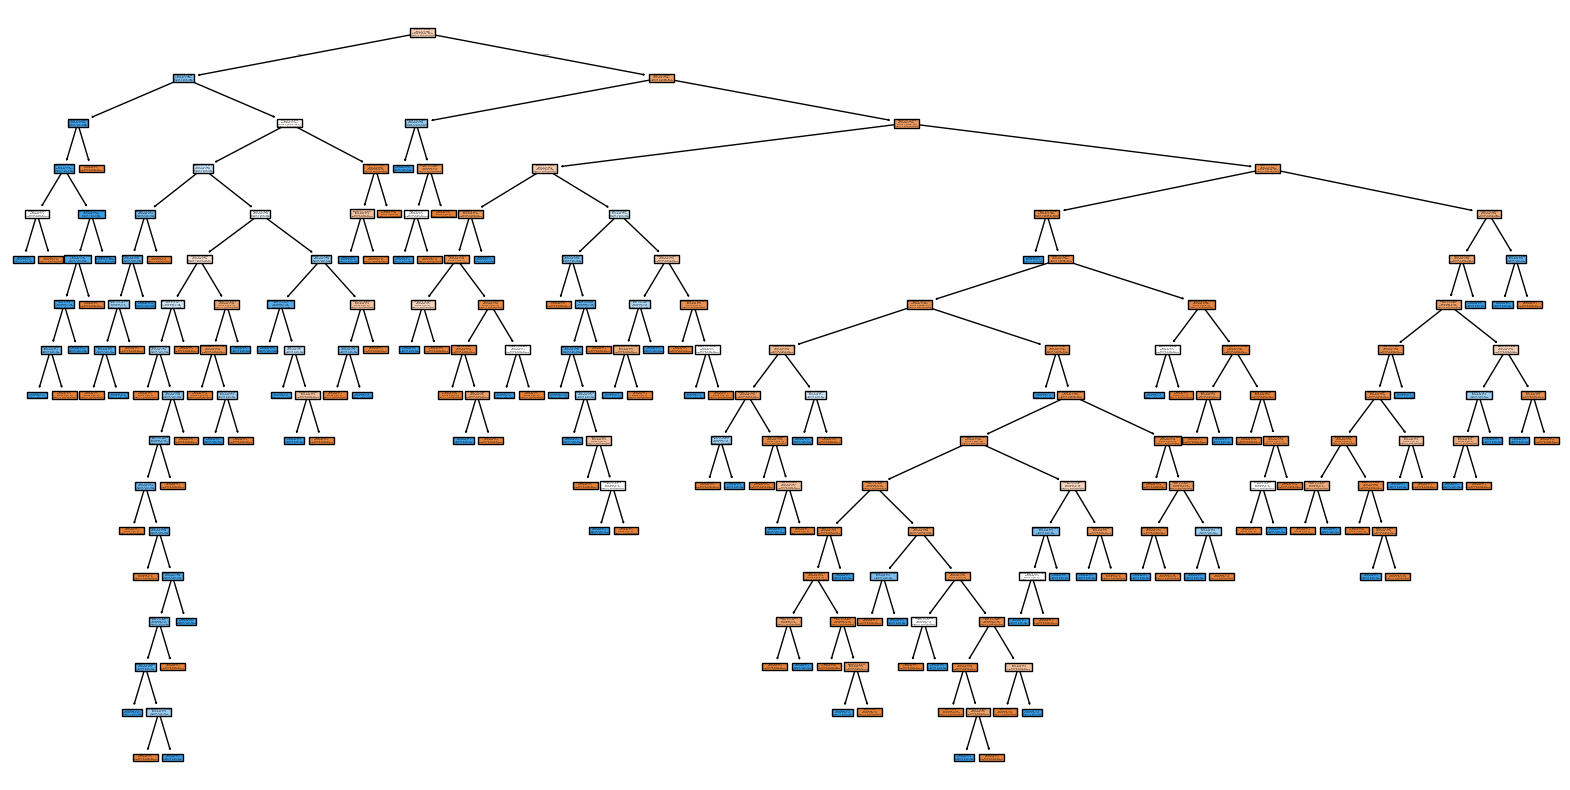

In [22]:
# Set up a large plot figure to accommodate the tree visualization
plt.figure(figsize=(20,10))

# Plot the tree with feature names and class labels, filled with colors for visualization
plot_tree(dt, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True)

# Display the plot
plt.show()
